In [9]:
import pandas as pd

In [123]:
df = pd.read_excel(r"C:\Users\subha\OneDrive\Desktop\Programming\python\dataAnalytics\Finlatics\ML_Research\Sales Prediction Dataset\advertising_sales_data.xlsx")

In [46]:
df.set_index('Campaign', inplace = True)

In [47]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [53]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,198.000000,200.000000,200.000000
mean,147.042500,23.260606,30.554000,15.130500
std,85.854236,14.921914,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.925000,12.750000,11.000000
50%,149.750000,22.400000,25.750000,16.000000
75%,218.825000,36.575000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [44]:
df['Campaign'] = [i for i in range(1, 201)]

'''
Advertising medium:
    1. TV: traditional and widely used medium for reaching a broad audience.
    2. Radio: specific demographics and local audiences.
    3. Newspaper: specific geographic regions or demographics.

Sales: units sold corresponding to the advertising expenditures

'''

In [31]:
#1.	What is the average amount spent on TV advertising in the dataset?

In [49]:
df.head()

,TV,Radio,Newspaper,Sales
Campaign,,,,
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,12.0
4,151.5,41.3,58.5,16.5
5,180.8,10.8,58.4,17.9


In [50]:
df['TV'].mean() #This is the average amount spent on advertising TV per campaign

np.float64(147.0425)

In [51]:
#2.	What is the correlation between radio advertising expenditure and product sales?

In [111]:
DF = pd.DataFrame(pd.cut(
    df['Radio'],
    bins=[10*i for i in range (0,6)]
))

DF['Sales'] = df['Sales']

In [112]:
DF['Radio'].value_counts()

Radio
(0, 10]     50
(20, 30]    39
(10, 20]    38
(30, 40]    35
(40, 50]    35
Name: count, dtype: int64

In [113]:
grouped1 = DF.groupby('Radio')['Sales'].median()

C:\Users\subha\AppData\Local\Temp\ipykernel_6740\2754721190.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped1 = DF.groupby('Radio')['Sales'].median()


In [74]:
import matplotlib.pyplot as plt

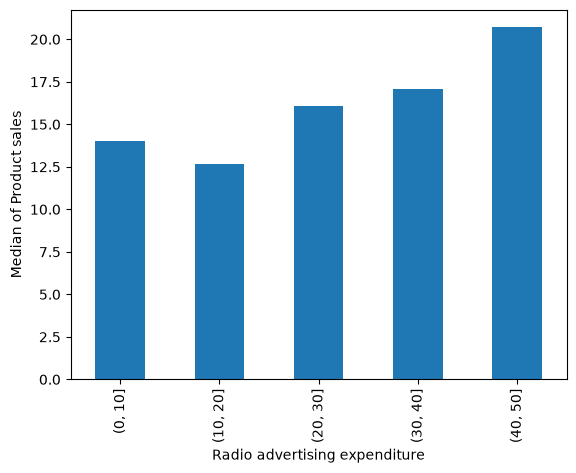

In [114]:
grouped1.plot(kind = 'bar')
plt.xlabel('Radio advertising expenditure')
plt.ylabel('Median of Product sales')
plt.show()

In [88]:
#3.	Which advertising medium has the highest impact on sales based on the dataset?

In [84]:
DF['TV'] = pd.DataFrame(pd.cut(
    df['TV'],
    bins=[10*i for i in range (0,31)],
))

In [86]:
DF['Newspaper'] = pd.DataFrame(pd.cut(
    df['Newspaper'],
    bins=[10*i for i in range (0,12)],
))

In [87]:
DF.head()

,Radio,Sales,TV,Newspaper
Campaign,,,,
1,30-40,22.1,"(230, 240]","(60, 70]"
2,30-40,10.4,"(40, 50]","(40, 50]"
3,40-50,12.0,"(10, 20]","(60, 70]"
4,40-50,16.5,"(150, 160]","(50, 60]"
5,10-20,17.9,"(180, 190]","(50, 60]"


In [105]:
grouped2 = DF.groupby('TV')['Sales'].median()

C:\Users\subha\AppData\Local\Temp\ipykernel_6740\191450716.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped2 = DF.groupby('TV')['Sales'].median()


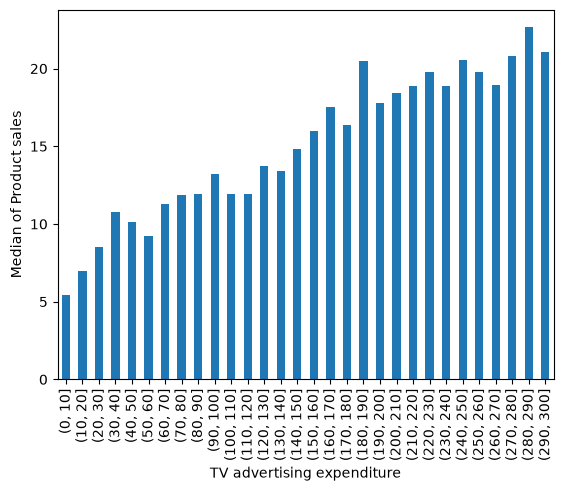

In [106]:
grouped2.plot(kind = 'bar')
plt.xlabel('TV advertising expenditure')
plt.ylabel('Median of Product sales')
plt.show()

In [109]:
grouped3 = DF.groupby('Newspaper')['Sales'].median()

C:\Users\subha\AppData\Local\Temp\ipykernel_6740\3793417319.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped3 = DF.groupby('Newspaper')['Sales'].median()


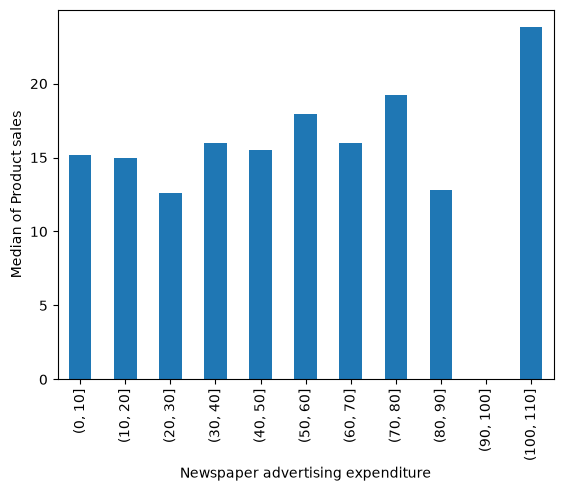

In [110]:
grouped3.plot(kind = 'bar')
plt.xlabel('Newspaper advertising expenditure')
plt.ylabel('Median of Product sales')
plt.show()

In [128]:
del DF
del [grouped1, grouped2, grouped3]

NameError: name 'DF' is not defined

In [192]:
#4.	Plot a linear regression line that includes all variables (TV, Radio, Newspaper) to predict Sales, and visualize the model's predictions against the actual sales values.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [193]:
df = df.dropna()

In [194]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [195]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [196]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.05,0.1 ,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.606
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [197]:
y_pred = model.predict(X_test)

In [198]:
'Intersept = '+ str(model.intercept_) # Model equation

'Intersept = 4.605745631298843'

In [199]:
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

print("\nR² Score =", r2_score(y_test, y_pred))
print("MSE =", mean_squared_error(y_test, y_pred))

TV: 0.05430344091434896
Radio: 0.10406871616421888
Newspaper: 0.0038080327479497744

R² Score = 0.89910282638328
MSE = 2.018623897648978


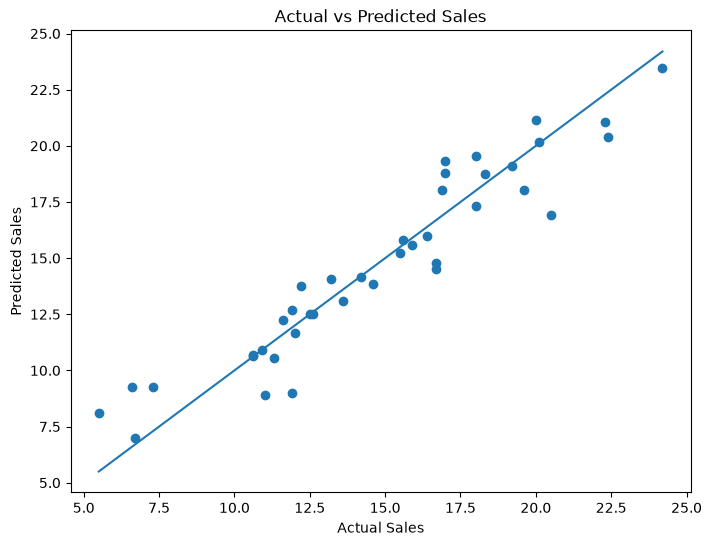

In [182]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

In [183]:
#5.	How would sales be predicted for a new set of advertising expenditures: $200 on TV, $40 on Radio, and $50 on Newspaper?

In [207]:
new_data = np.array([[200, 40, 50]])

'predicted_sales = '+ str(model.predict(new_data))

C:\Users\subha\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


'predicted_sales = [19.8195841]'

In [185]:
#6.	How does the performance of the linear regression model change when the dataset is normalized?

In [200]:
"Original R² = "+str(r2_score(y_test, y_pred))

'Original R² = 0.89910282638328'

In [201]:
from sklearn.preprocessing import MinMaxScaler

In [202]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

In [203]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[16.06, 5.16, 0.43]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.645
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[4.09,3.62,2.08]"


In [204]:
y_pred2 = model2.predict(X_test)

In [205]:
"Normalized R² = "+str(r2_score(y_test, y_pred2))

'Normalized R² = 0.89910282638328'

In [209]:
#7.	What is the impact on the sales prediction when only radio and newspaper advertising expenditures are used as predictors?

In [210]:
X = df[['Radio', 'Newspaper']]
y = df['Sales']

In [211]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [212]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.13,0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,11.79
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [213]:
y_pred = model.predict(X_test)

In [215]:
"R² =" + str(r2_score(y_test, y_pred))       #Bad prediction

'R² =-0.05191341464060373'